In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

#coffee_data = pd.read_csv(r"..\data\reduced_data_num.csv")
coffee_data = pd.read_csv(r"..\data\reduced_data_bin.csv")

column_names = coffee_data.drop(columns=['caffeine_class', 'caffeine_percent']).columns


filtered_data = coffee_data[coffee_data['caffeine_class'] == 1]

X = filtered_data.drop(columns=["caffeine_class", "caffeine_percent"])
y = filtered_data['caffeine_percent']

Preprocessing

In [15]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# ------------------------------------------------------------------------
# 1)  Work on a copy of the caffeine‑positive subset
df = filtered_data.copy()                    # filtered_data already has caffeine_class == 1
target = "caffeine_percent"
r_thresh = 0.10
rf_params = dict(n_estimators=200, random_state=42)

# ------------------------------------------------------------------------
# 2)  Drop predictors that are constant in this subset
zero_var = df.columns[df.nunique(dropna=False) == 1]
df = df.drop(columns=zero_var)

# ------------------------------------------------------------------------
# 3)  Univariate correlation screen
corr = df.drop(columns=[target]).corrwith(df[target]).abs()
keep_corr = corr[corr >= r_thresh].index                       # features with |r| ≥ 0.10

# ------------------------------------------------------------------------
# 4)  Model‑based screen (RF importance > 0)
rf = RandomForestRegressor(**rf_params).fit(df[keep_corr], df[target])
imp = pd.Series(rf.feature_importances_, index=keep_corr)
keep_rf = imp[imp > 0].index                                   # features actually used by RF

# ------------------------------------------------------------------------
# 5)  Final predictor set = intersection of steps 3 and 4
final_features = list(set(keep_corr) & set(keep_rf))

# ------------------------------------------------------------------------
# 6)  Design matrix and target vector
X = df[final_features].copy()
y = df[target].copy()

print(f"{len(final_features)} predictors retained:\n", final_features)

16 predictors retained:
 ['clim_60_pet5_may', 'env_76_soi_10', 'env_77_veg_14', 'env_73_asp', 'clim_69_cwd_annual', 'clim_70_ndm_per_year', 'env_79_forcov', 'clim_40_temp_season', 'env_76_soi_9', 'env_75_geo_10', 'env_71_alt', 'env_77_veg_16', 'env_78_wat_3', 'env_76_soi_11', 'clim_34_prec10_oct', 'clim_39_isotherm']


In [16]:
#from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define and train the XGBoost regressor
final_model = lgb.LGBMRegressor(
        objective="regression",
        n_estimators=800,
        learning_rate=0.01,
        num_leaves=4,
        min_data_in_leaf=3,
        feature_fraction=0.8,
        reg_alpha=0.3,
        reg_lambda=0.8,
        random_state=42
    )

#XGBRegressor(objective="reg:squarederror", n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
final_model.fit(X_train, y_train)

# Predict
y_pred = final_model.predict(X_test)

# Evaluation metrics
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("R²:", r2_score(y_test, y_pred))




[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000043 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 165
[LightGBM] [Info] Number of data points in the train set: 75, number of used features: 16
[LightGBM] [Info] Start training from score 0.085667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [19]:
import pandas as pd

file_path = r'../input/column_mapping.csv'  

# Read the CSV file into a DataFrame
column_mapping = pd.read_csv(file_path)

name_mapping = dict(zip(column_mapping['new_name'], column_mapping['long_name']))

# Replace feature names in the SHAP summary plot data
X_train_renamed = X_train.rename(columns=name_mapping)


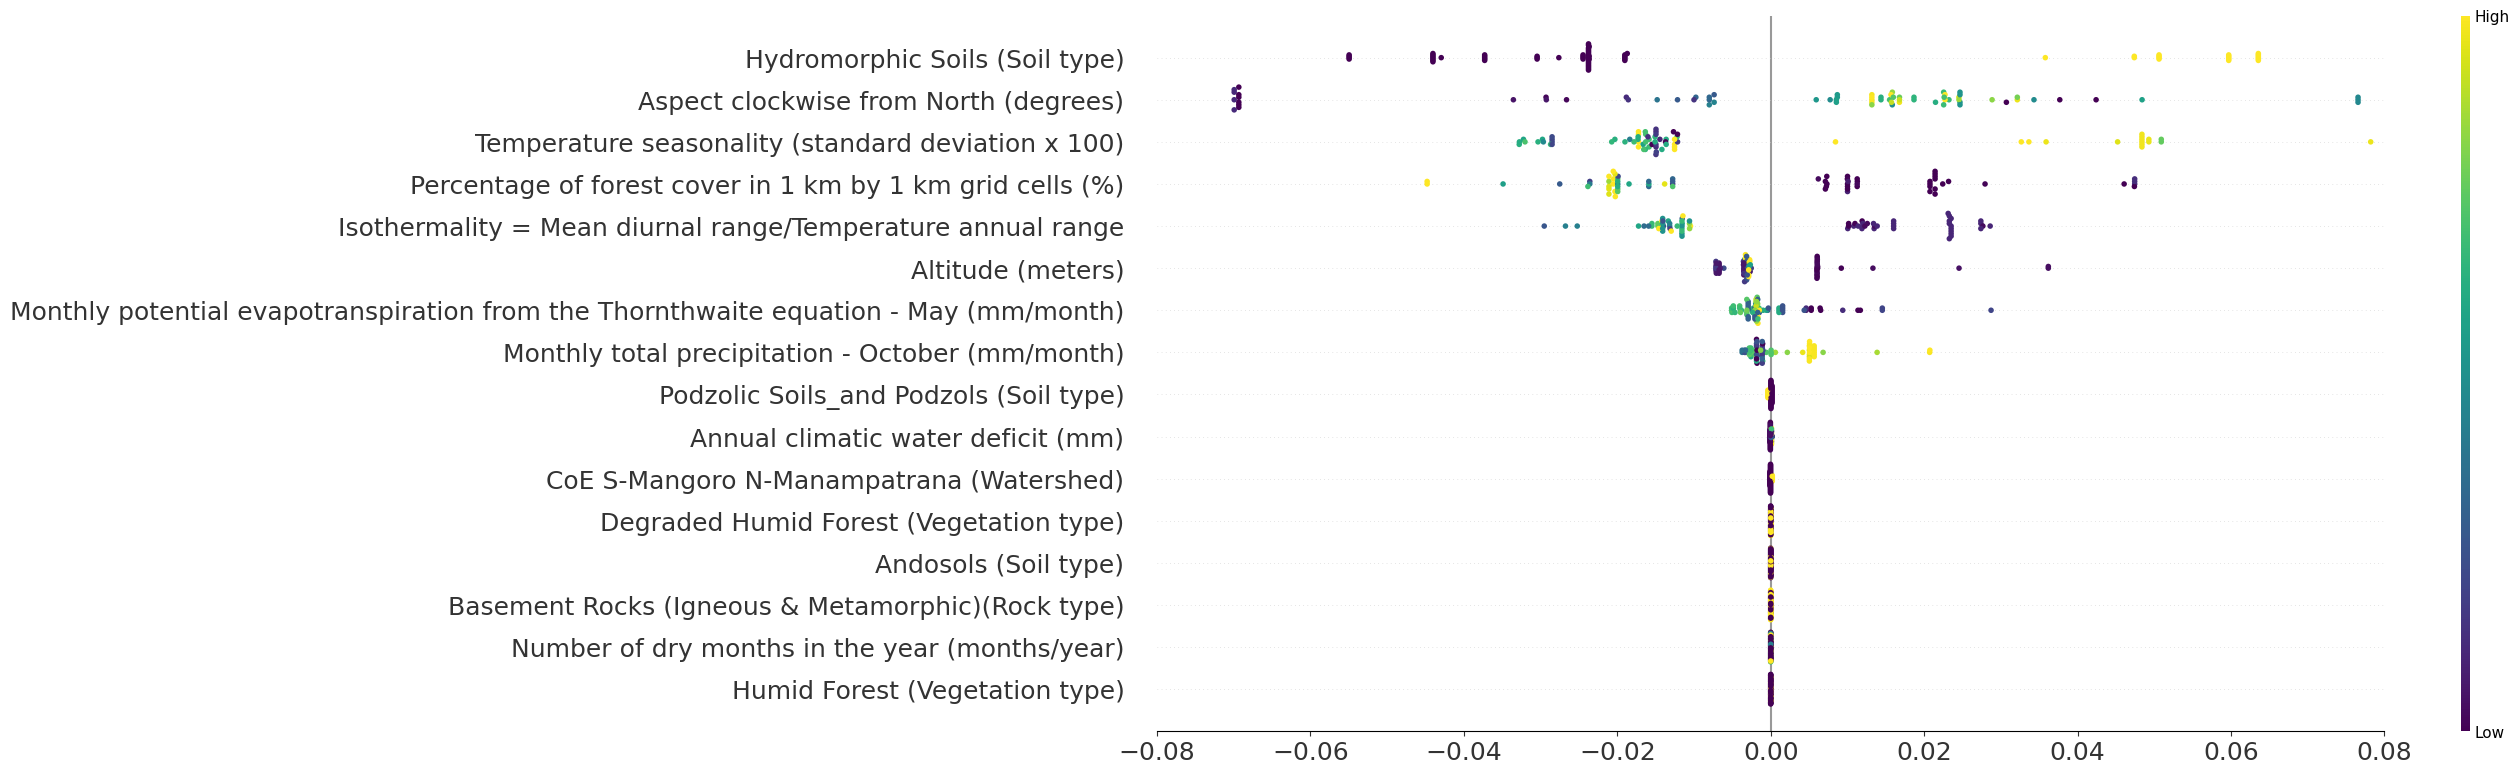

In [ ]:
import shap
import matplotlib.pyplot as plt

# No need to manually specify feature_perturbation — let SHAP auto-handle
explainer = shap.TreeExplainer(final_model, feature_perturbation = "interventional")

# Use a representative sample or full training data if memory allows
shap_values = explainer.shap_values(X_train_renamed)

# Plot for class 1 (assuming binary classification: [class 0, class 1])

#shap_values_class1 = shap_values[:, :, 1]  # shape = (360, 88)

if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]          # list-of-arrays format
else:
    shap_values_class1 = shap_values 

plt.figure(figsize=(14, 8))  # Adjust figure size for a wider plot
shap.summary_plot(shap_values_class1, X_train_renamed, plot_size=(24, 8), show=False, cmap='viridis')
plt.xlim(-0.08, 0.08)  # Expand x-axis limits to better view values around 0

fig = plt.gcf()
for ax in fig.axes:
    if 'colorbar' in ax.get_label().lower():
        colorbar = ax  # Identify the color bar axis
        colorbar.set_ylabel('')  # Remove the label from the color bar

#plt.title('SHAP Summary Plot')
plt.xlabel('')
plt.ylabel('')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.show()


#saved in images/SHAP_regression.png